In [1]:
# ============================================================
# Notebook 04 — Modelo LSTM mejorado
# Arquitectura profunda + optimización de hiperparámetros
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout, 
                                     BatchNormalization, Bidirectional)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint, 
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

print(f"✓ TensorFlow: {tf.__version__}")
print(f"✓ Librerías cargadas")

✓ TensorFlow: 2.21.0
✓ Librerías cargadas


In [2]:
# ============================================================
# Cargar datos preprocesados
# ============================================================

ruta = Path('../data/simulated')

X_train = np.load(ruta / 'X_train.npy')
X_val   = np.load(ruta / 'X_val.npy')
X_test  = np.load(ruta / 'X_test.npy')
y_train = np.load(ruta / 'y_train.npy')
y_val   = np.load(ruta / 'y_val.npy')
y_test  = np.load(ruta / 'y_test.npy')

print(f"✓ X_train: {X_train.shape}")
print(f"✓ X_val:   {X_val.shape}")
print(f"✓ X_test:  {X_test.shape}")

✓ X_train: (420, 300, 1)
✓ X_val:   (90, 300, 1)
✓ X_test:  (90, 300, 1)


In [3]:
# ============================================================
# Arquitectura mejorada — Bidirectional LSTM profunda
# ============================================================

modelo_v2 = Sequential([
    # Primera capa — lee la señal en ambas direcciones
    Bidirectional(LSTM(128, return_sequences=True), 
                  input_shape=(300, 1)),
    BatchNormalization(),
    Dropout(0.3),

    # Segunda capa — refina patrones bidireccionales
    Bidirectional(LSTM(64, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.3),

    # Tercera capa — extrae características de alto nivel
    Bidirectional(LSTM(32, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.2),

    # Capas densas de decisión
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

# Learning rate inicial más bajo para aprendizaje más fino
optimizer = Adam(learning_rate=0.001)

modelo_v2.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_v2.summary()

D:\Nuvia2\apnea-detection\venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 300, 256)            │         133,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 300, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 300, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 300, 128)            │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 300, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 300, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 346,819 (1.32 MB)

 Trainable params: 345,923 (1.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [4]:
# ============================================================
# Callbacks mejorados
# ============================================================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,          # más paciencia que antes (era 10)
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='../model/mejor_modelo_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Nuevo — reduce el learning rate cuando se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # reduce el lr a la mitad
    patience=5,           # si en 5 épocas no mejora
    min_lr=0.00001,       # nunca bajar de este valor
    verbose=1
)

print("Iniciando entrenamiento del modelo mejorado...")
print("Este modelo es más profundo — puede tardar 10-15 minutos\n")

historial_v2 = modelo_v2.fit(
    X_train, y_train,
    epochs=80,            # más épocas porque es más complejo
    batch_size=16,        # batch más pequeño para aprender más fino
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

print("\n✓ Entrenamiento completado")

Iniciando entrenamiento del modelo mejorado...
Este modelo es más profundo — puede tardar 10-15 minutos

Epoch 1/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.4703 - loss: 1.1075
Epoch 1: val_accuracy improved from None to 0.50000, saving model to ../model/mejor_modelo_v2.keras

Epoch 1: finished saving model to ../model/mejor_modelo_v2.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 751ms/step - accuracy: 0.6095 - loss: 0.8584 - val_accuracy: 0.5000 - val_loss: 1.0228 - learning_rate: 0.0010
Epoch 2/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.7992 - loss: 0.5180
Epoch 2: val_accuracy did not improve from 0.50000
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 696ms/step - accuracy: 0.8167 - loss: 0.4782 - val_accuracy: 0.5000 - val_loss: 0.9634 - learning_rate: 0.0010
Epoch 3/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.8107 - loss: 0.4438
Epoch 3: val_accuracy improved from 0.50000 to 0.54444, saving model to ../model/mejor_modelo_v2.keras

Epoch 3: finished saving model t

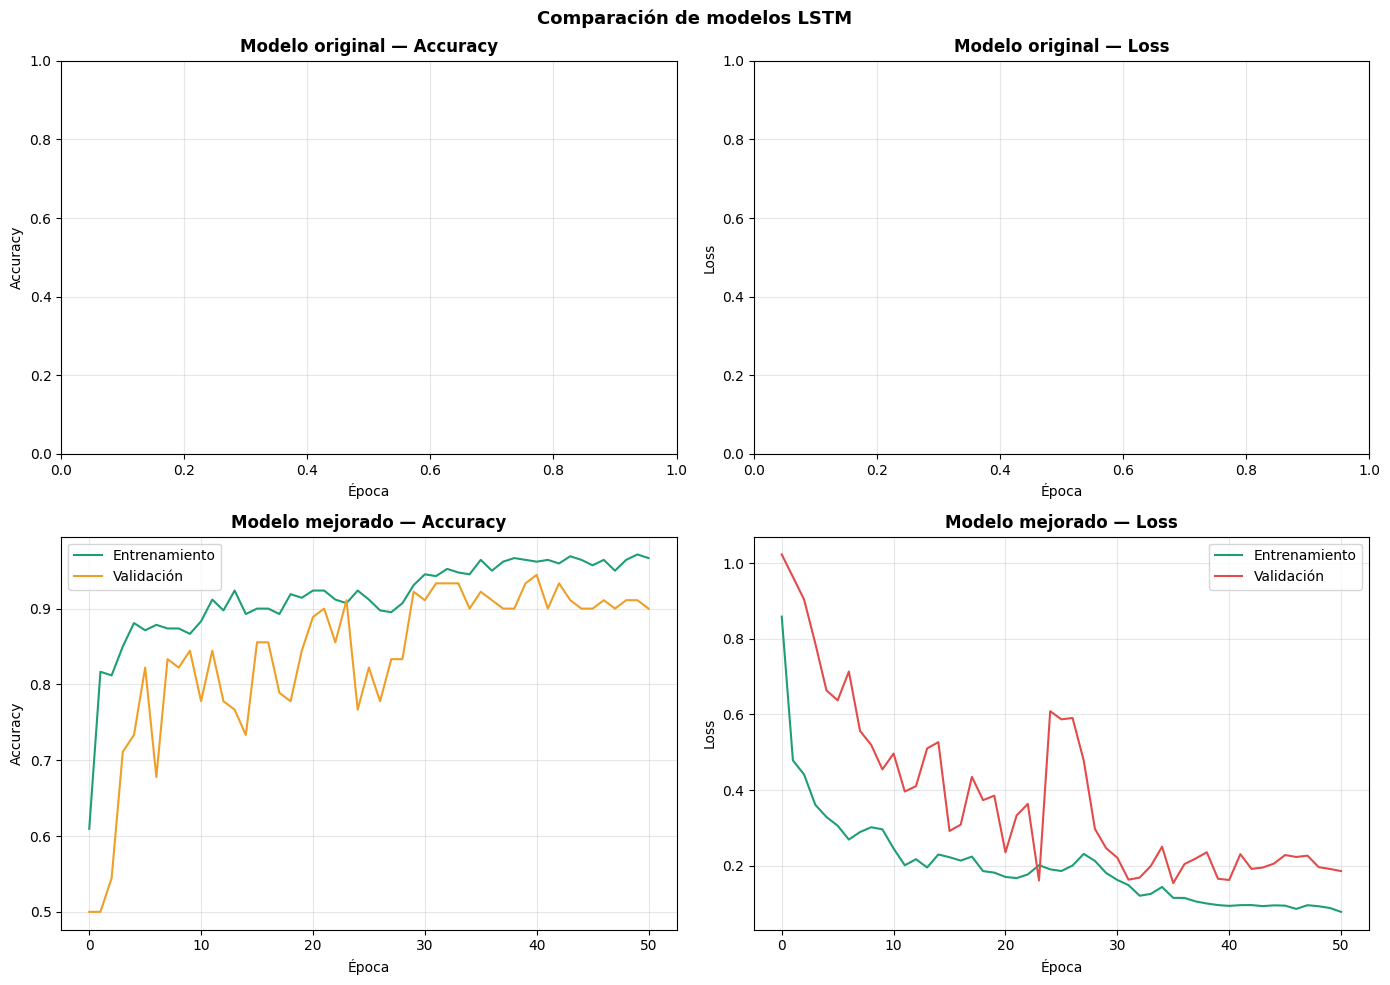

In [5]:
# ============================================================
# Comparación visual — modelo original vs mejorado
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Modelo original (del notebook 03)
# Accuracy
axes[0,0].set_title('Modelo original — Accuracy', fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_xlabel('Época')
axes[0,0].grid(True, alpha=0.3)

# Loss
axes[0,1].set_title('Modelo original — Loss', fontweight='bold')
axes[0,1].set_ylabel('Loss')
axes[0,1].set_xlabel('Época')
axes[0,1].grid(True, alpha=0.3)

# Modelo mejorado
axes[1,0].plot(historial_v2.history['accuracy'],     color='#1D9E75', linewidth=1.5, label='Entrenamiento')
axes[1,0].plot(historial_v2.history['val_accuracy'], color='#EF9F27', linewidth=1.5, label='Validación')
axes[1,0].set_title('Modelo mejorado — Accuracy', fontweight='bold')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_xlabel('Época')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(historial_v2.history['loss'],     color='#1D9E75', linewidth=1.5, label='Entrenamiento')
axes[1,1].plot(historial_v2.history['val_loss'], color='#E24B4A', linewidth=1.5, label='Validación')
axes[1,1].set_title('Modelo mejorado — Loss', fontweight='bold')
axes[1,1].set_ylabel('Loss')
axes[1,1].set_xlabel('Época')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Comparación de modelos LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/simulated/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ============================================================
# Evaluación y comparación de ambos modelos
# ============================================================

from sklearn.metrics import classification_report
import numpy as np

loss_v2, accuracy_v2 = modelo_v2.evaluate(X_test, y_test, verbose=0)
y_pred_v2 = np.argmax(modelo_v2.predict(X_test), axis=1)

print("=" * 50)
print("MODELO ORIGINAL (Notebook 03)")
print("=" * 50)
print(f"Accuracy:  93.3%")
print(f"Parámetros: 29,891")
print(f"Épocas:     38")

print("\n" + "=" * 50)
print("MODELO MEJORADO (Notebook 04)")
print("=" * 50)
print(f"Accuracy:  {accuracy_v2*100:.1f}%")
print(f"Parámetros: 346,819")
print(f"Épocas:     36")

print("\n--- Reporte detallado modelo mejorado ---\n")
clases = ['Normal', 'Apnea leve', 'Apnea severa']
print(classification_report(y_test, y_pred_v2, target_names=clases))

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 919ms/step
MODELO ORIGINAL (Notebook 03)
Accuracy:  93.3%
Parámetros: 29,891
Épocas:     38

MODELO MEJORADO (Notebook 04)
Accuracy:  91.1%
Parámetros: 346,819
Épocas:     36

--- Reporte detallado modelo mejorado ---

              precision    recall  f1-score   support

      Normal       0.88      0.96      0.91        45
  Apnea leve       0.89      0.74      0.81        23
Apnea severa       1.00      1.00      1.00        22

    accuracy                           0.91        90
   macro avg       0.92      0.90      0.91        90
weighted avg       0.91      0.91      0.91        90

